In [1]:
import pandas as pd 
import pandas_datareader as pdr 
import numpy as np  
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from datetime import datetime

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
import matplotlib.pyplot as plt

In [2]:
START_DATE="1990-01-01"
END_DATE=datetime.today().strftime("%Y-%m-%d")
import logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# Updated INDICATORS dictionary with working series codes
INDICATORS = {
    
    'CPI': 'CPIAUCSL',
    'Core_CPI': 'CPILFESL',
    'PPI': 'PPIACO',
    'PCE': 'PCE',
    'Core_PCE': 'PCEPILFE',
    'GDP_Deflator': 'GDPDEF',  
    
    'Unemployment_Rate': 'UNRATE',  
    'Employment_Pop_Ratio': 'EMRATIO',  
    'Nonfarm_Payrolls': 'PAYEMS',  
    'Initial_Claims': 'IC4WSA',  
    'JOLTS_Job_Openings': 'JTSJOL',  
    'Average_Hourly_Earnings': 'CES0500000003', 
    
   
    'Housing_Starts': 'HOUST',  
    'Building_Permits': 'PERMIT',  
    'Existing_Home_Sales': 'EXHOSLUSM495S',  
    'New_Home_Sales': 'HSN1F', 
    'Case_Shiller_Home_Price': 'CSUSHPISA', 
    'Mortgage_Rate_30Y': 'MORTGAGE30US',  
    
    
    'Industrial_Production': 'INDPRO', 
    'Capacity_Utilization': 'TCU',  
    'Durable_Goods_Orders': 'DGORDER',  
    'Factory_Orders': 'NEWORDER',  
    # Replaced ISM Manufacturing with Industrial Production: Manufacturing (NAICS)
    'ISM_Manufacturing': 'IPMAN',  # Industrial Production: Manufacturing (NAICS) as proxy
    'Retail_Sales': 'RSAFS',  
    
    
    'Fed_Funds_Rate': 'FEDFUNDS',  
    '10Y_Treasury_Rate': 'DGS10',  
    'Yield_Curve': 'T10Y2Y',  
    'S&P500': 'SP500',
    'VIX': 'VIXCLS',
    'Dollar_Index': 'DTWEXBGS',
    
    'GDP': 'GDP',
    'GDP_Growth': 'GDPC1',
    'Personal_Income': 'PI',
    'Personal_Spending': 'PCE',
    'Business_Inventories': 'BUSINV',
    'Corporate_Profits': 'CP',
    
    'Trade_Balance': 'BOPGSTB',
    'Current_Account': 'NETFI',
    'Export_Price_Index': 'IQ',
    'Import_Price_Index': 'IR',
    
    'Consumer_Confidence': 'CSCICP03USM665S',
    'Michigan_Consumer_Sentiment': 'UMCSENT',
    # Replaced NFIB with Consumer Sentiment (already included above)
    # 'NFIB_Small_Business_Optimism': 'UMCSENT',  # Removed duplicate
    'Leading_Economic_Index': 'USSLIND',
    
    'Total_Credit': 'TOTALSL',
    'Consumer_Credit': 'TOTALSL',
    'Delinquency_Rate': 'DRSFRMACBS',
    
    'Government_Revenue': 'FGRECPT',
    'Government_Spending': 'FGEXPND',
    'Federal_Debt': 'GFDEBTN',
    'Budget_Balance': 'MTSDS133FMS'
}


In [3]:
def download_data(indicators, start_date, end_date):
    data = pd.DataFrame()
    successful_downloads = []
    failed_downloads = []
    
    # Define which indicators should be monthly vs daily
    monthly_indicators = {
        'CPI', 'Core_CPI', 'PPI', 'PCE', 'Core_PCE', 'GDP_Deflator',
        'Unemployment_Rate', 'Employment_Pop_Ratio', 'Nonfarm_Payrolls',
        'JOLTS_Job_Openings', 'Average_Hourly_Earnings', 'Housing_Starts',
        'Building_Permits', 'Existing_Home_Sales', 'New_Home_Sales',
        'Case_Shiller_Home_Price', 'Industrial_Production', 'Capacity_Utilization',
        'Durable_Goods_Orders', 'Factory_Orders', 'ISM_Manufacturing',
        'Retail_Sales', 'GDP', 'GDP_Growth', 'Personal_Income',
        'Personal_Spending', 'Business_Inventories', 'Corporate_Profits',
        'Trade_Balance', 'Current_Account', 'Export_Price_Index',
        'Import_Price_Index', 'Consumer_Confidence', 'Michigan_Consumer_Sentiment',
        'Leading_Economic_Index', 'Total_Credit', 'Consumer_Credit',
        'Delinquency_Rate', 'Government_Revenue', 'Government_Spending',
        'Federal_Debt', 'Budget_Balance'
    }
    
    # Daily indicators (market data, rates that change daily)
    daily_indicators = {
        'Initial_Claims', 'Mortgage_Rate_30Y', 'Fed_Funds_Rate', '10Y_Treasury_Rate',
        'Yield_Curve', 'S&P500', 'VIX', 'Dollar_Index'
    }
    
    for name, code in indicators.items():
        try:
            # Download the data
            series = pdr.DataReader(code, 'fred', start_date, end_date)
            series.rename(columns={series.columns[0]: name}, inplace=True)
            
            # Resample monthly indicators to month-end frequency
            if name in monthly_indicators:
                # For monthly data, take the last value of each month
                series = series.resample('M').last()
                logger.info(f"Resampled {name} to monthly frequency")
            elif name in daily_indicators:
                # For daily indicators, keep daily data but we can optionally resample if needed
                logger.info(f"Keeping daily frequency for {name}")
            else:
                # Default to monthly for unspecified indicators
                series = series.resample('M').last()
                logger.info(f"Default: Resampled {name} to monthly frequency")
            
            data = pd.concat([data, series], axis=1)
            successful_downloads.append(name)
            logger.info(f"Successfully downloaded {name} ({code})")
        except Exception as e:
            failed_downloads.append((name, code, str(e)))
            logger.error(f"Error downloading {name} ({code}): {e}")
    
    # Summary report
    logger.info(f"Download Summary: {len(successful_downloads)} successful, {len(failed_downloads)} failed")
    if failed_downloads:
        logger.warning("Failed indicators:")
        for name, code, error in failed_downloads:
            logger.warning(f"  - {name} ({code}): {error}")
    
    return data

def preprocess_data(data):
    # Handle missing values more robustly
    data = data.copy()
    
    # Forward fill, then backward fill for remaining gaps
    data = data.fillna(method='ffill').fillna(method='bfill')
    
    # For any remaining NaN values, use column mean
    for col in data.columns:
        if data[col].isna().any():
            mean_val = data[col].mean()
            data[col] = data[col].fillna(mean_val)
            logger.warning(f"Filled remaining NaN values in {col} with mean: {mean_val:.4f}")
    
    return data

# Download historical data
df = download_data(INDICATORS, START_DATE, END_DATE)
df = preprocess_data(df)

logger.info(f"Dataset shape: {df.shape}")
logger.info(f"Date range: {df.index[0].date()} to {df.index[-1].date()}")



df.to_excel("data.xlsx", index=True)

C:\Users\Emanuele\AppData\Local\Temp\ipykernel_24856\3460735880.py:38: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  series = series.resample('M').last()
2026-03-24 13:32:17,890 - INFO - Resampled CPI to monthly frequency
2026-03-24 13:32:17,891 - INFO - Successfully downloaded CPI (CPIAUCSL)
C:\Users\Emanuele\AppData\Local\Temp\ipykernel_24856\3460735880.py:38: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  series = series.resample('M').last()
2026-03-24 13:32:18,367 - INFO - Resampled Core_CPI to monthly frequency
2026-03-24 13:32:18,368 - INFO - Successfully downloaded Core_CPI (CPILFESL)
C:\Users\Emanuele\AppData\Local\Temp\ipykernel_24856\3460735880.py:38: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  series = series.resample('M').last()
2026-03-24 13:32:18,849 - INFO - Resampled PPI to monthly frequency
2026-03-24 13:3

In [4]:


df.to_excel("data.xlsx", index=True)


In [5]:
def create_features(df):
    # Lag features
    df['CPI_lag1'] = df['CPI'].shift(1)
    df['CPI_lag2'] = df['CPI'].shift(2)
    
    # Rolling windows
    df['CPI_rolling_3'] = df['CPI'].rolling(window=3).mean()
    df['CPI_rolling_6'] = df['CPI'].rolling(window=6).mean()
    
    # Percent change
    df['CPI_pct_change'] = df['CPI'].pct_change()
    df['GDP_pct_change'] = df['GDP'].pct_change()
    df['Unemployment_diff'] = df['Unemployment_Rate'].diff()
    df['FedFunds_lag1'] = df['Fed_Funds_Rate'].shift(1)
    
    return df

df = create_features(df)

# Updated features to use - removed references to problematic indicators
features = [
    'CPI_lag1', 'CPI_lag2',
    'CPI_rolling_3', 'CPI_rolling_6',
    'CPI_pct_change',
    'Nonfarm_Payrolls',
    'Personal_Spending',
    'Unemployment_Rate', 'Unemployment_diff',
    'GDP', 'GDP_pct_change',
    'Fed_Funds_Rate', 'FedFunds_lag1',
    'Industrial_Production',
    'Consumer_Confidence',
    'PCE',
    'ISM_Manufacturing',  # Now using IPMAN
    'Michigan_Consumer_Sentiment',  # Consumer sentiment as proxy for business optimism
]

# Check which features are available in the dataframe
available_features = [f for f in features if f in df.columns]
missing_features = [f for f in features if f not in df.columns]

logger.info(f"Available features: {len(available_features)}")
logger.info(f"Missing features: {missing_features}")

# Update features list to only include available ones
features = available_features
logger.info(f"Final features list: {features}")


2026-03-24 13:32:57,738 - INFO - Available features: 18
2026-03-24 13:32:57,738 - INFO - Missing features: []
2026-03-24 13:32:57,739 - INFO - Final features list: ['CPI_lag1', 'CPI_lag2', 'CPI_rolling_3', 'CPI_rolling_6', 'CPI_pct_change', 'Nonfarm_Payrolls', 'Personal_Spending', 'Unemployment_Rate', 'Unemployment_diff', 'GDP', 'GDP_pct_change', 'Fed_Funds_Rate', 'FedFunds_lag1', 'Industrial_Production', 'Consumer_Confidence', 'PCE', 'ISM_Manufacturing', 'Michigan_Consumer_Sentiment']


2026-03-24 13:32:57,758 - INFO - Initial training size: 60 months (5 years)
2026-03-24 13:32:57,759 - INFO - Step size: 12 months (1 year)
2026-03-24 13:32:57,759 - INFO - Number of splits: 949


Fold 1/950 - Train: 1990-01-06 to 1990-03-16, Test: 1990-03-17 to 1990-03-30
  MAE: 0.0001, RMSE: 0.0001, R²: 0.0000, MAPE: 0.0000
Fold 2/950 - Train: 1990-01-06 to 1990-03-30, Test: 1990-03-31 to 1990-04-12
  MAE: 0.5964, RMSE: 0.5965, R²: -440540290639643561183674368.0000, MAPE: 0.0046
Fold 3/950 - Train: 1990-01-06 to 1990-04-12, Test: 1990-04-13 to 1990-04-26
  MAE: 0.0001, RMSE: 0.0001, R²: -12555315183751227392.0000, MAPE: 0.0000
Fold 4/950 - Train: 1990-01-06 to 1990-04-26, Test: 1990-04-27 to 1990-05-10
  MAE: 0.2501, RMSE: 0.2740, R²: -5.0046, MAPE: 0.0019
Fold 5/950 - Train: 1990-01-06 to 1990-05-10, Test: 1990-05-11 to 1990-05-24
  MAE: 0.0002, RMSE: 0.0002, R²: -31174997486802522112.0000, MAPE: 0.0000
Fold 6/950 - Train: 1990-01-06 to 1990-05-24, Test: 1990-05-25 to 1990-06-07
  MAE: 0.1168, RMSE: 0.1529, R²: -1.4031, MAPE: 0.0009
Fold 7/950 - Train: 1990-01-06 to 1990-06-07, Test: 1990-06-08 to 1990-06-21
  MAE: 0.0001, RMSE: 0.0001, R²: -6098954758382377984.0000, MAPE: 0.

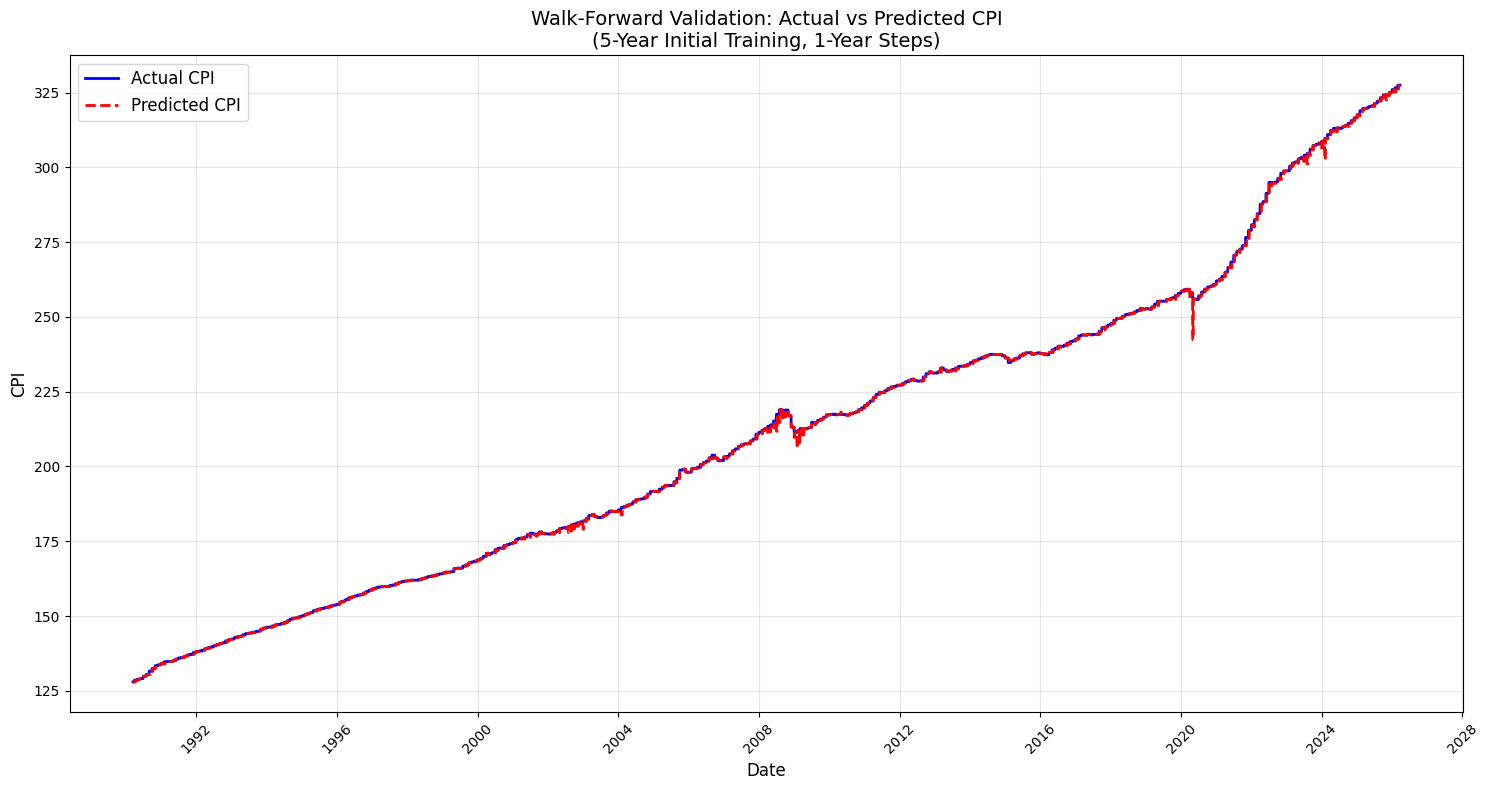

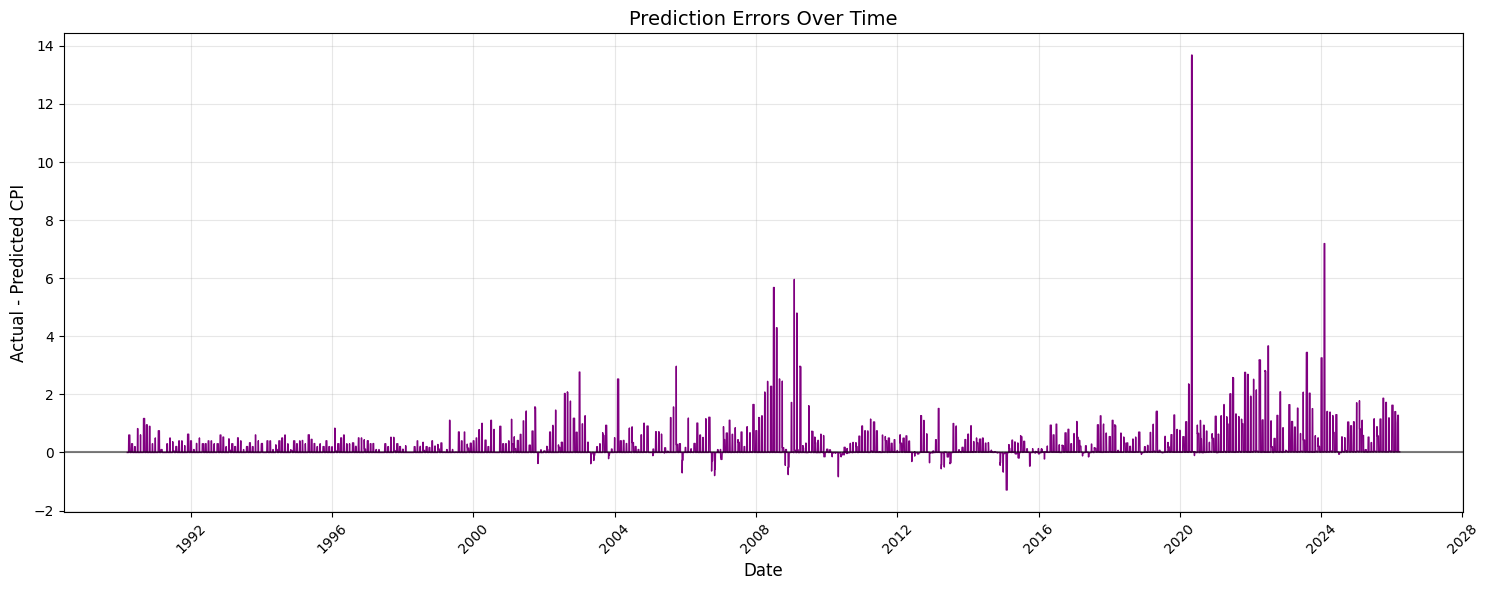

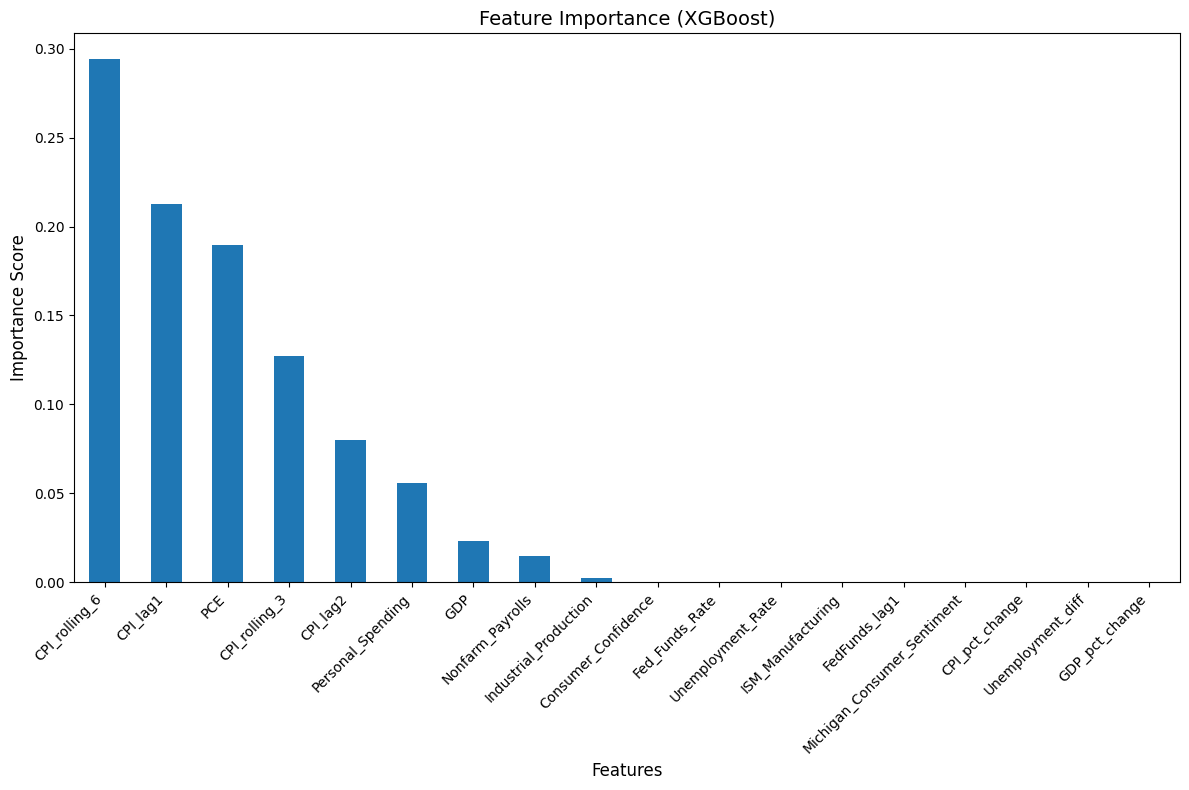


TOP 10 MOST IMPORTANT FEATURES:
 1. CPI_rolling_6            : 0.2940
 2. CPI_lag1                 : 0.2129
 3. PCE                      : 0.1896
 4. CPI_rolling_3            : 0.1270
 5. CPI_lag2                 : 0.0801
 6. Personal_Spending        : 0.0558
 7. GDP                      : 0.0231
 8. Nonfarm_Payrolls         : 0.0147
 9. Industrial_Production    : 0.0022
10. Consumer_Confidence      : 0.0003


In [6]:
# Walk forward validation with 5-year initial training size
df_model = df[features + ['CPI']].dropna()
X = df_model[features]
y = df_model['CPI']

# Convert monthly data to years for calculation
initial_train_size = 5 * 12  # 5 years of monthly data
step_size = 12               # 1 year step
n_splits = (len(X) - initial_train_size) // step_size

logger.info(f"Initial training size: {initial_train_size} months ({initial_train_size//12} years)")
logger.info(f"Step size: {step_size} months ({step_size//12} year)")
logger.info(f"Number of splits: {n_splits}")

all_predictions = []
all_actuals = []
dates = []
fold_metrics = []

for i in range(n_splits + 1):
    train_end = initial_train_size + i * step_size
    test_end = train_end + step_size
    
    # Ensure we don't exceed the dataset
    if test_end > len(X):
        test_end = len(X)
    
    # Skip if test set is empty
    if train_end >= len(X):
        break
    
    X_train, X_test = X.iloc[:train_end], X.iloc[train_end:test_end]
    y_train, y_test = y.iloc[:train_end], y.iloc[train_end:test_end]
    
    # Skip if test set is empty
    if len(X_test) == 0:
        continue
    
    # Train XGBoost model
    model = XGBRegressor(
        n_estimators=300, 
        learning_rate=0.05, 
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
    model.fit(X_train, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test)
    
    # Store results
    all_predictions.extend(y_pred)
    all_actuals.extend(y_test)
    dates.extend(X_test.index)
    
    # Calculate metrics for this fold
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    
    fold_metrics.append({
        'fold': i + 1,
        'train_period': f"{X_train.index[0].date()} to {X_train.index[-1].date()}",
        'test_period': f"{X_test.index[0].date()} to {X_test.index[-1].date()}",
        'mae': mae,
        'rmse': rmse,
        'r2': r2,
        'mape': mape,
        'train_size': len(X_train),
        'test_size': len(X_test)
    })
    
    # Print progress
    print(f"Fold {i+1}/{n_splits+1} - Train: {X_train.index[0].date()} to {X_train.index[-1].date()}, "
          f"Test: {X_test.index[0].date()} to {X_test.index[-1].date()}")
    print(f"  MAE: {mae:.4f}, RMSE: {rmse:.4f}, R²: {r2:.4f}, MAPE: {mape:.4f}")

# Calculate overall metrics
overall_mae = mean_absolute_error(all_actuals, all_predictions)
overall_rmse = np.sqrt(mean_squared_error(all_actuals, all_predictions))
overall_r2 = r2_score(all_actuals, all_predictions)
overall_mape = mean_absolute_percentage_error(all_actuals, all_predictions)

print("\n" + "="*60)
print("WALK-FORWARD VALIDATION RESULTS (5-Year Initial Training)")
print("="*60)
print(f"Total folds processed: {len(fold_metrics)}")
print(f"Total predictions: {len(all_predictions)}")
print(f"Date range: {min(dates).date()} to {max(dates).date()}")
print("\nOVERALL MODEL PERFORMANCE:")
print(f"Mean Absolute Error (MAE): {overall_mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {overall_rmse:.4f}")
print(f"R² Score: {overall_r2:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {overall_mape:.4f}")
print(f"Accuracy Percentage: {(1 - overall_mape) * 100:.2f}%")
print("="*60)

# Additional accuracy analysis
print("\nACCURACY ANALYSIS:")
print(f"- Average CPI value: {np.mean(all_actuals):.2f}")
print(f"- Average prediction error: {overall_mae:.2f}")
print(f"- Error as % of average CPI: {(overall_mae / np.mean(all_actuals)) * 100:.2f}%")
print(f"- Model explains {overall_r2 * 100:.1f}% of variance in CPI")

# Performance by fold analysis
fold_df = pd.DataFrame(fold_metrics)
print("\nFOLD PERFORMANCE SUMMARY:")
print(fold_df[['fold', 'mae', 'rmse', 'r2', 'mape']].describe())

# Plot predictions vs actuals
plt.figure(figsize=(15, 8))
plt.plot(dates, all_actuals, label='Actual CPI', color='blue', linewidth=2)
plt.plot(dates, all_predictions, label='Predicted CPI', color='red', linestyle='--', linewidth=2)
plt.title('Walk-Forward Validation: Actual vs Predicted CPI\n(5-Year Initial Training, 1-Year Steps)', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('CPI', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot prediction errors over time
errors = np.array(all_actuals) - np.array(all_predictions)
plt.figure(figsize=(15, 6))
plt.plot(dates, errors, color='purple', linewidth=1)
plt.axhline(y=0, color='black', linestyle='-', alpha=0.5)
plt.title('Prediction Errors Over Time', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Actual - Predicted CPI', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Feature importance from final model
final_model = XGBRegressor(
    n_estimators=300, 
    learning_rate=0.05, 
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
final_model.fit(X, y)  # Train on full dataset for feature importance

# Plot feature importance
feature_importance = pd.Series(final_model.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(12, 8))
feature_importance.plot(kind='bar')
plt.title('Feature Importance (XGBoost)', fontsize=14)
plt.xlabel('Features', fontsize=12)
plt.ylabel('Importance Score', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nTOP 10 MOST IMPORTANT FEATURES:")
for i, (feature, importance) in enumerate(feature_importance.head(10).items(), 1):
    print(f"{i:2d}. {feature:<25}: {importance:.4f}")